### Necessary imports and Libaries

In [20]:
import os
import logging
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import numpy as np
import logging
import datetime
import nibabel as nib
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, roc_curve, roc_auc_score, precision_score
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Subset, random_split, Dataset
from torch.utils.data import *
from torch.nn.parallel import DataParallel

### Hyperparameters

In [21]:
VAL_RATIO = 0.2
TEST_RATIO = 0.2
TRAIN_RATIO = 1 - VAL_RATIO - TEST_RATIO
DATA_PARALELL = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET = 'OASIS3'
PHASE = 'TRAIN'
K_FOLDS = 5

TASK = 'detection'
ROOT_DIR = '/kaggle/input/oasis-1-shinohara/oasis/OASIS'
LABEL_DIR='/kaggle/input/oasis-1-shinohara/oasis_cross-sectional.csv'
LOG_DIR = '/kaggle/working/logs'
timestamp = datetime.datetime.now().strftime('%d_%m_%Y_%H_%M_%S')
RESULT_DIR = f'/kaggle/working/results/run_{timestamp}'
os.makedirs(RESULT_DIR,exist_ok=True)
TEST_BATCH_SIZE = 8

BATCH_SIZE=8
LEARNING_RATE=0.0001
NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 5

NP_SEED = 48
TORCH_SEED = 32

### Setting the seed

In [22]:
np.random.seed(NP_SEED)
torch.manual_seed(TORCH_SEED)

### Setting up logger

In [23]:
def setup_logger(logs_dir=LOG_DIR,dataset=None,phase=None):
    os.makedirs(logs_dir, exist_ok=True)
    logger = logging.getLogger('RunLogger')
    logger.setLevel(logging.INFO)

    if not logger.hasHandlers():
        timestamp = datetime.datetime.now().strftime('%d_%m_%Y_%H_%M_%S')
        file_handler = logging.FileHandler(os.path.join(logs_dir, f'{phase}_{dataset}_{timestamp}.log'))
        formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        file_handler.setFormatter(formatter)
        logger.addHandler(file_handler)
    
    return logger

LOGGER = setup_logger(logs_dir=LOG_DIR,phase=PHASE,dataset=DATASET)

### Dataset Class

In [24]:
class MRIdata(Dataset):
    """
    Dataset class for loading neuroimaging data and associated labels for classification or regression tasks.

    Attributes:
        root_dir (str): Path to the directory containing image data files (.nii or .nii.gz).
        label_dir (str): Path to the CSV file containing labels for each subject.
        task (str): Specifies the task type: classification (Gender) or regression (Age).
    """
    def __init__(self, root_dir, label_dir, task='classification'):
        self.labels_df = self.load_labels(label_dir) #load the labels
        self.samples = self.make_dataset(root_dir, task=task) #assign the labels to each file in the root_dir

    def __len__(self):
        return len(self.samples)
    
    def __getposweight__(self):
        class_labels = []
        for path, label, age, gender in dataset.samples:
            class_labels.append(label)
        return sum(class_labels)/(len(class_labels)-sum(class_labels))

    def __getitem__(self, idx):
        img_path, label, age, gender = self.samples[idx]
        nifti_data = nib.load(img_path)
        data = nifti_data.get_fdata()
        image_tensor = torch.tensor(data, dtype=torch.float32).unsqueeze(0) #unsqueeze to add channel dimension
        label_tensor = torch.tensor(label, dtype=torch.float32).unsqueeze(0)
        age_tensor = torch.tensor(age, dtype=torch.float32).unsqueeze(0)
        gender_tensor = torch.tensor(gender, dtype=torch.float32).unsqueeze(0)
        return image_tensor, label_tensor, age_tensor, gender_tensor
       
    def make_dataset(self, root_dir, task = None):
        samples = []
        labels_df = self.labels_df
        for root, _, fnames in os.walk(root_dir):
            for fname in fnames:
                if fname.endswith(".nii.gz") or fname.endswith(".nii"):
                    if "MR2" in fname :
                        continue
                    path = os.path.join(root, fname)
                    id_ = self.extract_id_from_filename(fname)
                    try:
                        age = labels_df[labels_df['ID'] == id_]['Age'].iloc[0] / 100.0
                        gender = labels_df[labels_df['ID'] == id_]['Gender'].iloc[0]
                        if task == 'regression': 
                            label = labels_df[labels_df['ID'] == id_]['Age'].iloc[0] / 100.0
                        if task == 'classification': 
                            label = labels_df[labels_df['ID'] == id_]['Gender'].iloc[0]
                        if task == 'detection': 
                            cdr = labels_df[labels_df['ID'] == id_]['CDR'].iloc[0]
                            label = 0.0 if cdr == 0.0 else 1.0 #make all the groups of AD as a single group
                        samples.append((path, label, age, gender))
                    except:
                        continue
        return samples
    
    def extract_id_from_filename(self, fname):
        '''match the filename to key to query in the labels dictionary
        OAS1_0004_MR1_mpr_n4_anon_sbj_111_normalised.nii extract only the first 13 characters from this file to match the ID column of the .csv file
        '''
        
        return fname[:13]

    def load_labels(self, label_path):
        '''tip: use astype(required datatype)'''
        df = pd.read_csv(label_path)
        df_filtered = df[['ID', 'M/F', 'Age','CDR']].copy()
        df_filtered['Gender'] = df_filtered['M/F'].map({'M': 0, 'F': 1}).astype(int)
        df_filtered['Age'] = df_filtered['Age'].astype(float).round()
        df_filtered['ID'] = df_filtered['ID'].astype(str)
        df_filtered['CDR'] = df_filtered['CDR'].astype(float)
        return df_filtered

### Create the dataset and split into training and testing

In [25]:
dataset = MRIdata(root_dir=ROOT_DIR,label_dir=LABEL_DIR,task=TASK)
train_dataset, val_dataset, test_dataset = random_split(dataset, [TRAIN_RATIO, VAL_RATIO, TEST_RATIO])

In [26]:
global_pos_weight = dataset.__getposweight__()
global_pos_weight

0.31645569620253167

In [27]:
class_labels = []
for path, label, age, gender in dataset.samples:
    class_labels.append(label)
    
total_samples = len(class_labels)
count_class_1 = sum(class_labels)
count_class_0 = total_samples - count_class_1
ratio_class_1_to_class_0 = count_class_1 / count_class_0 if count_class_0 > 0 else None

total_samples, count_class_1, count_class_0, ratio_class_1_to_class_0

(416, 100.0, 316.0, 0.31645569620253167)

### Dataloder

In [28]:
train_dl = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False)

### Comparing the shape of image at each stage

In [29]:
RANDOM_IMAGE_PATH = '/kaggle/input/oasis-1-shinohara/oasis/OASIS/OAS1_0002_MR1_mpr_n4_anon_sbj_111_normalised.nii'
raw_image = nib.load(RANDOM_IMAGE_PATH).get_fdata()
train_image = train_dataset.__getitem__(1)[0]
train_batch = next(iter(train_dl))

print('Raw image shape',raw_image.shape,'\n' 'Train image shape', train_image.shape,'\n' 'Batch shape',train_batch[0].shape)

Raw image shape (91, 109, 91) 
Train image shape torch.Size([1, 91, 109, 91]) 
Batch shape torch.Size([8, 1, 91, 109, 91])


### Stratify the labels for classification

In [30]:
def stratified_split_classification(dataset, test_size):
    labels = [dataset[i][1] for i in range(len(dataset))]  # Assuming label is the last element
    # cannot access sample variable for all instances, will thorw AttributeError: 'Subset' object has no attribute 'samples'
    train_indices, test_indices = train_test_split(
        range(dataset.__len__()), test_size=test_size, stratify=labels
    )
    train_ds = Subset(dataset, train_indices)
    test_ds = Subset(dataset, test_indices)
    return train_ds, test_ds

def splitting_data(dataset, TEST_RATIO: float, stratify: bool=False):
    if stratify:
        train_ds, test_ds = stratified_split_classification(dataset, TEST_RATIO)
    else:
        train_ds, test_ds = random_split(dataset, [1-TEST_RATIO, TEST_RATIO])
    return train_ds, test_ds

In [31]:
train_and_val_ds, test_ds = stratified_split_classification(dataset, test_size=TEST_RATIO)
train_ds, val_ds = stratified_split_classification(train_and_val_ds, test_size=VAL_RATIO)
LOGGER.info('Data split completed !!')

### verifying

In [32]:
dataset_labels = []
for ds in [train_ds, val_ds, test_ds]:
    labels = []
    for i, j, _, _ in ds:
        labels.append(j)
    dataset_labels.append(labels)
    
for num, phase in enumerate(['Train', 'Val', 'Test']):
    Total_subjects = len(dataset_labels[num]), 
    males_count = len(dataset_labels[num]) - sum(dataset_labels[num])
    females_count = sum(dataset_labels[num]), 
    ratio = (len(dataset_labels[num]) - sum(dataset_labels[num])) / sum(dataset_labels[num])
    print(f'Phase {phase}, total: {Total_subjects[0]}, ratio: {ratio}')

Phase Train, total: 265, ratio: tensor([3.1406])
Phase Val, total: 67, ratio: tensor([3.1875])
Phase Test, total: 84, ratio: tensor([3.2000])


In [33]:
train_dl = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False)

### model

In [34]:
class SFCN(nn.Module):
    def __init__(self, channel_number=[32, 64, 128, 256, 256, 64], output_dim=1, dropout=True):  # default output_dim changed from 40 to 1
        super(SFCN, self).__init__()
        n_layer = len(channel_number)

        # Feature extractor
        self.feature_extractor = nn.Sequential()
        for i in range(n_layer):
            if i == 0:
                in_channel = 1
            else:
                in_channel = channel_number[i - 1]
            out_channel = channel_number[i]
            if i < n_layer - 1:
                self.feature_extractor.add_module(
                    f'conv_{i}',
                    self.conv_layer(in_channel, out_channel, maxpool=True, kernel_size=3, padding=1)
                )
            else:
                self.feature_extractor.add_module(
                    f'conv_{i}',
                    self.conv_layer(in_channel, out_channel, maxpool=False, kernel_size=1, padding=0)
                )

        # Global average pooling
        self.global_avg_pool = nn.AdaptiveAvgPool3d(1)  # Output shape: [batch_size, channels, 1, 1, 1]

        # Optional dropout
        self.use_dropout = dropout
        if dropout:
            self.dropout = nn.Dropout(0.5)

        # Fully connected layer to handle concatenated features
        in_features = channel_number[-1] + 2  # Add 2 for x_age and x_gender
        self.fc = nn.Conv3d(in_features, output_dim, kernel_size=1)  # Final output layer

    @staticmethod
    def conv_layer(in_channel, out_channel, maxpool=True, kernel_size=3, padding=0, maxpool_stride=2):
        if maxpool:
            layer = nn.Sequential(
                nn.Conv3d(in_channel, out_channel, padding=padding, kernel_size=kernel_size),
                nn.BatchNorm3d(out_channel),
                nn.MaxPool3d(2, stride=maxpool_stride),
                nn.ReLU(),
            )
        else:
            layer = nn.Sequential(
                nn.Conv3d(in_channel, out_channel, padding=padding, kernel_size=kernel_size),
                nn.BatchNorm3d(out_channel),
                nn.ReLU(),
            )
        return layer

    def forward(self, x, x_age, x_gender):
        """
        Forward pass of the SFCN model, modified to include x_age and x_gender after global average pooling.
        """
        # Feature extraction
        x_f = self.feature_extractor(x)  # Shape: [batch_size, channels, d, h, w]

        # Global average pooling
        x_pooled = self.global_avg_pool(x_f)  # Shape: [batch_size, channels, 1, 1, 1]
        x_pooled = x_pooled.view(x_pooled.size(0), -1)  # Flatten to [batch_size, channels]

        # Concatenate x_age and x_gender
        x_age_gender = torch.cat((x_pooled, x_age, x_gender), dim=1)  # Shape: [batch_size, channels + 2]

        # Apply dropout if enabled
        if self.use_dropout:
            x_age_gender = self.dropout(x_age_gender)

        # Final output layer
        x_age_gender = x_age_gender.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)  # Reshape to [batch_size, channels + 2, 1, 1, 1]
        x_out = self.fc(x_age_gender)  # Shape: [batch_size, output_dim, 1, 1, 1]

        return x_out.view(x_out.size(0), -1)

In [35]:
from torchinfo import summary

batch_size = 16
input_image_shape = (1, 91, 109, 91)  # Shape of the MRI input
age_input = torch.randn(batch_size, 1)  # Age input
gender_input = torch.randn(batch_size, 1)  # Gender input

model = SFCN(channel_number=[32, 64, 128, 256, 256, 64], output_dim=1, dropout=True)

summary(
    model=model,
    input_data=(torch.randn(batch_size, *input_image_shape), age_input, gender_input),
    # col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"],
    # verbose=2,
    # depth=3
)

Layer (type:depth-idx)                   Output Shape              Param #
SFCN                                     [16, 1]                   --
├─Sequential: 1-1                        [16, 64, 2, 3, 2]         --
│    └─Sequential: 2-1                   [16, 32, 45, 54, 45]      --
│    │    └─Conv3d: 3-1                  [16, 32, 91, 109, 91]     896
│    │    └─BatchNorm3d: 3-2             [16, 32, 91, 109, 91]     64
│    │    └─MaxPool3d: 3-3               [16, 32, 45, 54, 45]      --
│    │    └─ReLU: 3-4                    [16, 32, 45, 54, 45]      --
│    └─Sequential: 2-2                   [16, 64, 22, 27, 22]      --
│    │    └─Conv3d: 3-5                  [16, 64, 45, 54, 45]      55,360
│    │    └─BatchNorm3d: 3-6             [16, 64, 45, 54, 45]      128
│    │    └─MaxPool3d: 3-7               [16, 64, 22, 27, 22]      --
│    │    └─ReLU: 3-8                    [16, 64, 22, 27, 22]      --
│    └─Sequential: 2-3                   [16, 128, 11, 13, 11]     --
│    │   

### K-Fold Cross Validation for Training with early stopping

In [36]:
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=NP_SEED)
fold_train_losses, fold_val_losses = [], []
fold_train_accuracies, fold_val_accuracies = [], []
LOGGER.info(f"{K_FOLDS} FOLDS CROSS VALIATION TARINING STARTED")

for fold, (train_idx, val_idx) in enumerate(kf.split(train_dataset)):
    print(f'Fold {fold+1}/{K_FOLDS}')
    LOGGER.info(f'Fold {fold+1}/{K_FOLDS}')
    
    train_ds = Subset(train_dataset, train_idx)
    val_ds = Subset(train_dataset, val_idx)
    
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = SFCN().to(DEVICE)
    model = nn.DataParallel(model) 
    
    best_model = SFCN()
    
    optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
    
    criterion = nn.BCEWithLogitsLoss()
    # criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(global_pos_weight,dtype=torch.float32))

    best_val_loss = np.inf
    epochs_without_improvement = 0

    # Train the model for each fold
    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0.0
        train_total = 0
        train_correct = 0

        for inputs, labels, age, gender in train_dl:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            age = age.to(DEVICE)
            gender = gender.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs, age, gender)
            tloss = criterion(outputs, labels)
            tloss.backward()
            optimizer.step()
            train_loss += tloss.item() / inputs.size(0)
            probability = torch.sigmoid(outputs)
            predicted = (probability >= 0.5).float()
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_accuracy = 100 * train_correct / train_total
        fold_train_accuracies.append(train_accuracy)
        fold_train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        val_total = 0
        val_correct = 0

        with torch.no_grad():
            for inputs, labels, age, gender in val_dl:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                age = age.to(DEVICE)
                gender = gender.to(DEVICE)
                
                outputs = model(inputs, age, gender)
                vloss = criterion(outputs, labels)
                val_loss += vloss.item() / inputs.size(0)
                probability = torch.sigmoid(outputs)
                predicted = (probability >= 0.5).float()
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

            val_accuracy = 100 * val_correct / val_total
            fold_val_accuracies.append(val_accuracy)
            fold_val_losses.append(val_loss)

            print(f"Fold [{fold+1}/{K_FOLDS}], Epoch [{epoch+1}/{NUM_EPOCHS}]: Train Loss: {train_loss:.4f} Train Accu: {train_accuracy:.2f}% Val Loss: {val_loss:.4f} Val Accu: {val_accuracy:.2f}%")
            LOGGER.info(f"Fold [{fold+1}/{K_FOLDS}], Epoch [{epoch+1}/{NUM_EPOCHS}]: Train Loss: {train_loss:.4f} Train Accu: {train_accuracy:.2f}% Val Loss: {val_loss:.4f} Val Accu: {val_accuracy:.2f}%")
        
        # Early stopping
        if epoch > 30:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_without_improvement = 0 

                new_state_dict = {}
                for key, value in model.state_dict().items():
                    new_key = key.replace("module.", "")
                    new_state_dict[new_key] = value
                best_model.load_state_dict(new_state_dict)

                # torch.save(model.state_dict(), f'{RESULT_DIR}/model_{fold+1}_epoch{epoch}.pt') # will create a lot of model and take a lot of space
                LOGGER.info(f"Validation loss improved for fold {fold+1} at epoch {epoch+1}")
            else:
                epochs_without_improvement += 1
                LOGGER.info(f"No improvement in validation loss for {epochs_without_improvement} epochs for fold {fold+1}")

            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping triggered for fold {fold+1} at epoch {epoch+1}")
                LOGGER.info(f"Early stopping triggered for fold {fold+1} at epoch {epoch+1}")
                ## save best model before stopping
                torch.save(model.state_dict(), f'{RESULT_DIR}/best_model_{fold+1}_epoch{epoch}.pt')
                break
    
    torch.save(model.state_dict(), f'{RESULT_DIR}/best_model_{fold+1}_epoch{epoch}.pt') ## save model as best model if the training ends for a fold

# Aggregate the results across all folds
avg_train_loss = np.mean(fold_train_losses)
avg_val_loss = np.mean(fold_val_losses)
avg_train_accuracy = np.mean(fold_train_accuracies)
avg_val_accuracy = np.mean(fold_val_accuracies)

print(f"Avg Train Loss: {avg_train_loss:.4f}, Avg Train Accu: {avg_train_accuracy:.2f}%, Avg Val Loss: {avg_val_loss:.4f}, Avg Val Accu: {avg_val_accuracy:.2f}%")
LOGGER.info(f"Avg Train Loss: {avg_train_loss:.4f}, Avg Train Accu: {avg_train_accuracy:.2f}%, Avg Val Loss: {avg_val_loss:.4f}, Avg Val Accu: {avg_val_accuracy:.2f}%")

Fold 1/2
Fold [1/2], Epoch [1/5]: Train Loss: 1.4286 Train Accu: 28.00% Val Loss: 1.9656 Val Accu: 20.00%
Fold [1/2], Epoch [2/5]: Train Loss: 1.4253 Train Accu: 28.80% Val Loss: 2.1820 Val Accu: 20.00%
Fold [1/2], Epoch [3/5]: Train Loss: 1.3428 Train Accu: 35.20% Val Loss: 1.7645 Val Accu: 20.00%
Fold [1/2], Epoch [4/5]: Train Loss: 1.3763 Train Accu: 28.80% Val Loss: 1.4799 Val Accu: 21.60%
Fold [1/2], Epoch [5/5]: Train Loss: 1.3140 Train Accu: 42.40% Val Loss: 1.4262 Val Accu: 20.80%
Fold 2/2
Fold [2/2], Epoch [1/5]: Train Loss: 1.2900 Train Accu: 39.20% Val Loss: 1.3215 Val Accu: 23.20%
Fold [2/2], Epoch [2/5]: Train Loss: 1.3203 Train Accu: 42.40% Val Loss: 1.3458 Val Accu: 23.20%
Fold [2/2], Epoch [3/5]: Train Loss: 1.2332 Train Accu: 56.80% Val Loss: 1.2920 Val Accu: 23.20%
Fold [2/2], Epoch [4/5]: Train Loss: 1.2402 Train Accu: 51.20% Val Loss: 1.2343 Val Accu: 46.40%
Fold [2/2], Epoch [5/5]: Train Loss: 1.2325 Train Accu: 52.80% Val Loss: 1.2194 Val Accu: 57.60%
Avg Train Lo

Testing remains the same

TEST LOSS: 1.0360786442955334, TEST ACCURACY: 25.301204819277107
Accuracy: 0.25301204819277107, Sensitivity (Recall): 0.9130434782608695, Specificity: 0.0, Precision: 0.25925925925925924
CM:  [[ 0 60]
 [ 2 21]]
TEST LOSS: 0.9367473771174749, TEST ACCURACY: 50.602409638554214
Accuracy: 0.5060240963855421, Sensitivity (Recall): 0.8260869565217391, Specificity: 0.38333333333333336, Precision: 0.3392857142857143
CM:  [[23 37]
 [ 4 19]]


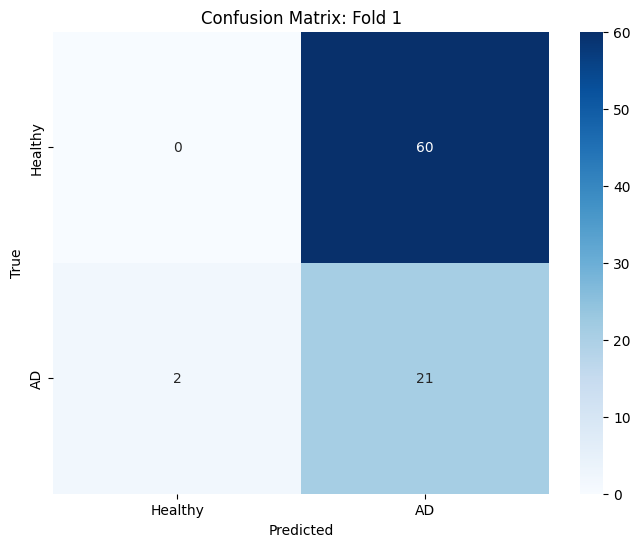

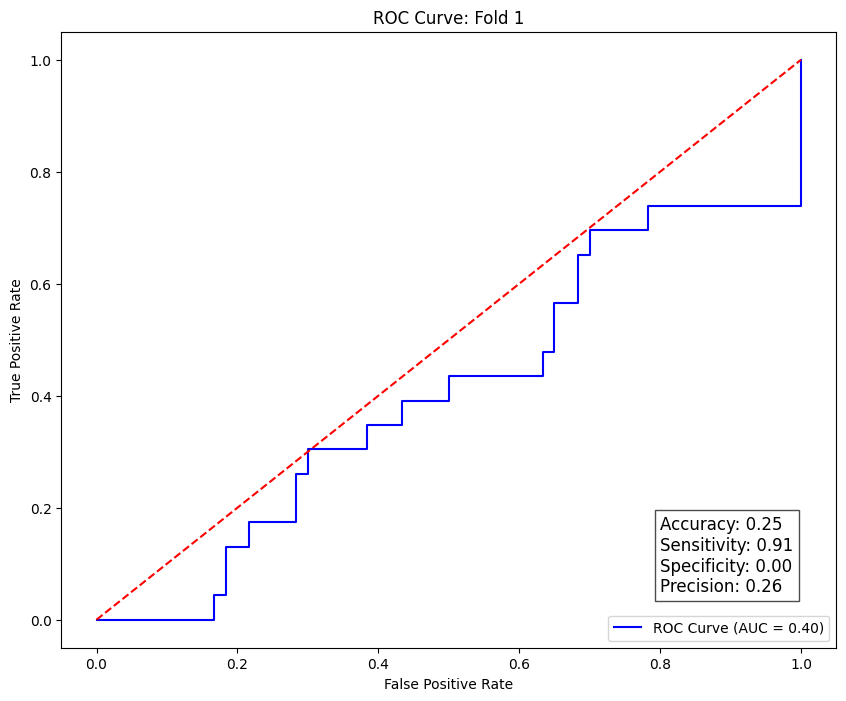

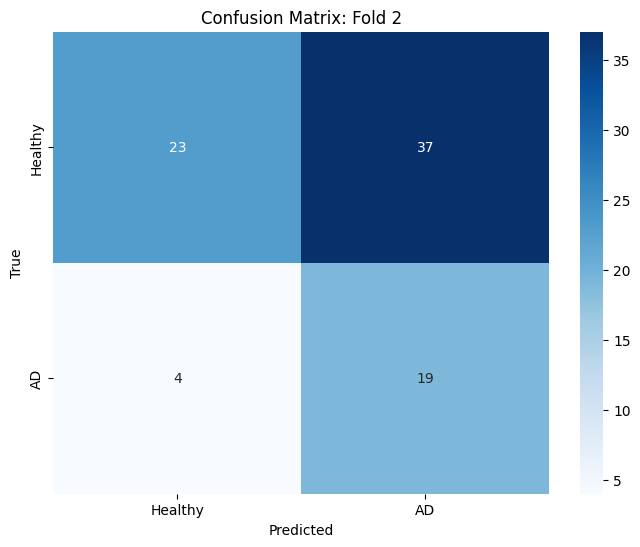

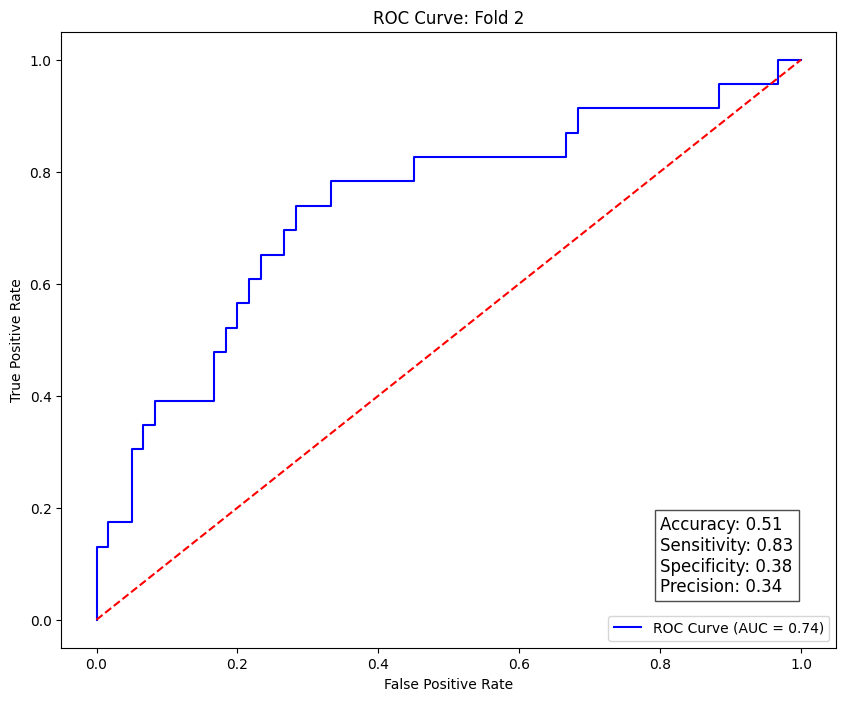

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Existing code is assumed to be here
for best_model_per_fold in os.listdir(RESULT_DIR):
    if best_model_per_fold.endswith(".pt"):
        fold_number = best_model_per_fold.split("_")[2]
        best_model = SFCN()
        best_model_state_dict = torch.load(f'{RESULT_DIR}/{best_model_per_fold}', weights_only=True) #choose the best performing fold
        
        new_state_dict = {}
        for key, value in best_model_state_dict.items():
            new_key = key.replace("module.", "")
            new_state_dict[new_key] = value
        best_model.load_state_dict(new_state_dict)

        best_model.to(DEVICE)
        best_model.eval()
        test_loss = 0.0
        test_total = 0
        test_correct = 0
        
        with torch.no_grad():
            all_predicted = []
            all_labels = []
            all_probabilities = []  # To store probabilities for ROC curve
            for inputs, labels, age, gender in test_dl:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                age = age.to(DEVICE)
                gender = gender.to(DEVICE)
                
                outputs = best_model(inputs, age, gender)
                
                te_loss = criterion(outputs, labels)
                test_loss += te_loss.item()/inputs.size(0)
                probability = torch.sigmoid(outputs)
                predicted = (probability >= 0.5).float()
                all_probabilities.extend(probability.cpu().numpy().ravel().tolist())
                all_predicted.extend(predicted.cpu().numpy().ravel().tolist())
                all_labels.extend(labels.cpu().numpy().ravel().tolist())
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()
        
            test_accuracy = 100 * test_correct / test_total

        cm = confusion_matrix(all_labels, all_predicted)
        
        print(f"TEST LOSS: {test_loss}, TEST ACCURACY: {test_accuracy}")
        LOGGER.info(f"TEST LOSS: {test_loss}, TEST ACCURACY: {test_accuracy}")
        accuracy = accuracy_score(all_labels, all_predicted)
        sensitivity = recall_score(all_labels, all_predicted)
        specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
        precision = precision_score(all_labels, all_predicted)
        
        print(f'Accuracy: {accuracy}, Sensitivity (Recall): {sensitivity}, Specificity: {specificity}, Precision: {precision}')
        LOGGER.info(f'Accuracy: {accuracy}, Sensitivity (Recall): {sensitivity}, Specificity: {specificity}, Precision: {precision}')
        
        print('CM: ',cm)
        LOGGER.info(f"CM for Fold {fold_number} : {cm}")
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",xticklabels=['Healthy', 'AD'], yticklabels=['Healthy', 'AD'])
        plt.title(f'Confusion Matrix: Fold {fold_number}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.savefig(f'cm_fold{fold_number}.png')

        # Plot ROC Curve
        fpr, tpr, thresholds = roc_curve(all_labels, all_probabilities)
        auc_score = roc_auc_score(all_labels, all_probabilities)
        
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
        plt.plot([0, 1], [0, 1], color='red', linestyle='--')
        plt.title(f'ROC Curve: Fold {fold_number}')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc='lower right')

        # Annotate the metrics on the plot
        text = (
            f"Accuracy: {accuracy:.2f}\n"
            f"Sensitivity: {sensitivity:.2f}\n"
            f"Specificity: {specificity:.2f}\n"
            f"Precision: {precision:.2f}"
        )
        plt.text(0.8, 0.05, text, fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

        plt.savefig(f'roc_fold{fold_number}.png')
        # plt.close()


TEST LOSS: 1.0360786442955334, TEST ACCURACY: 25.301204819277107
Accuracy: 0.25301204819277107, Sensitivity (Recall): 0.9130434782608695, Specificity: 0.0, Precision: 0.25925925925925924
CM:  [[ 0 60]
 [ 2 21]]
TEST LOSS: 0.9367473771174749, TEST ACCURACY: 50.602409638554214
Accuracy: 0.5060240963855421, Sensitivity (Recall): 0.8260869565217391, Specificity: 0.38333333333333336, Precision: 0.3392857142857143
CM:  [[23 37]
 [ 4 19]]


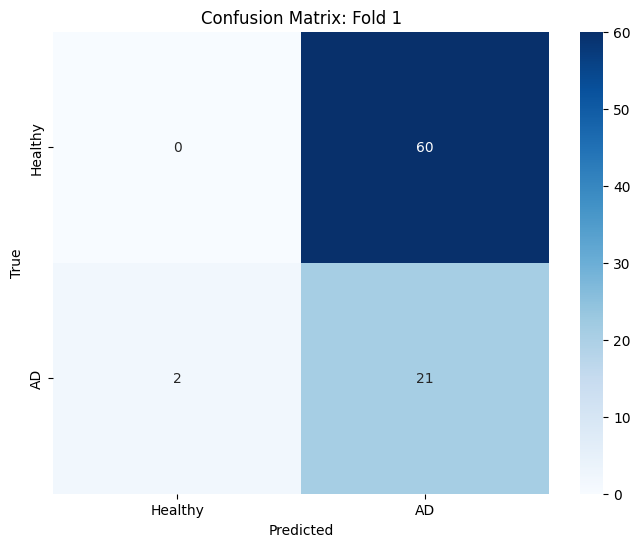

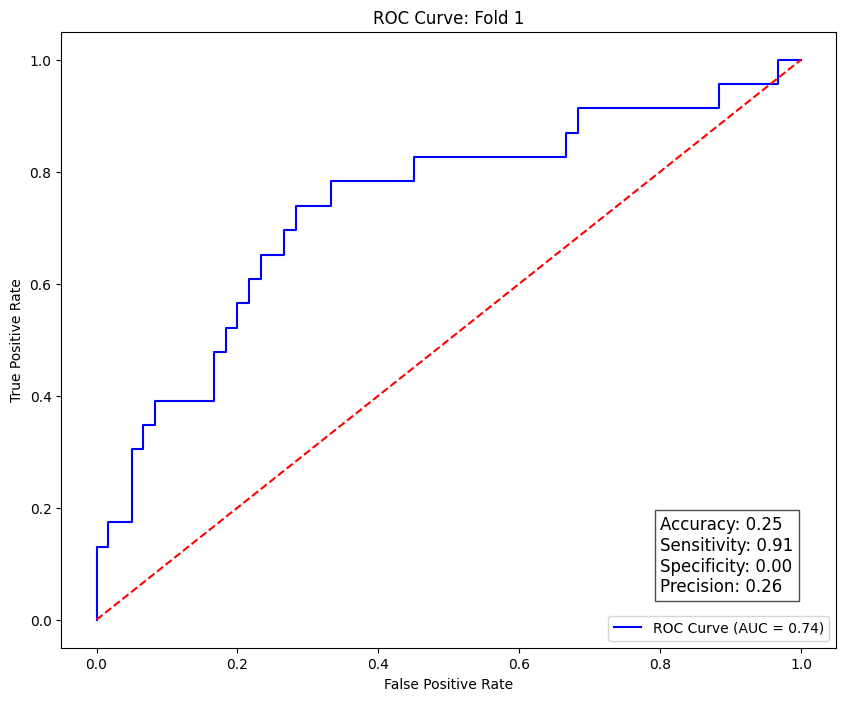

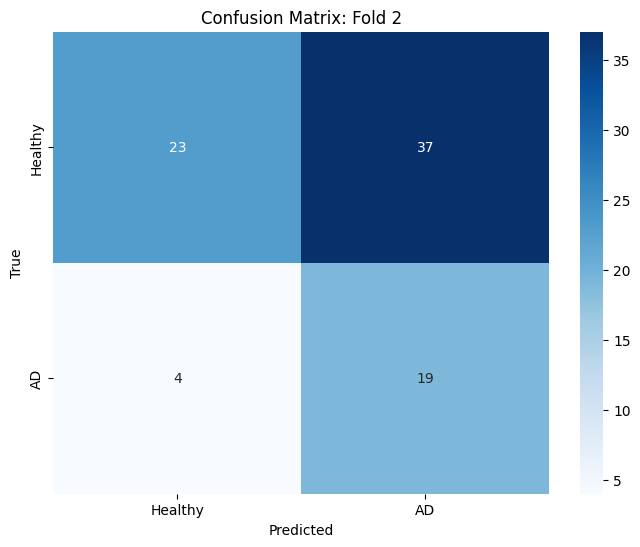

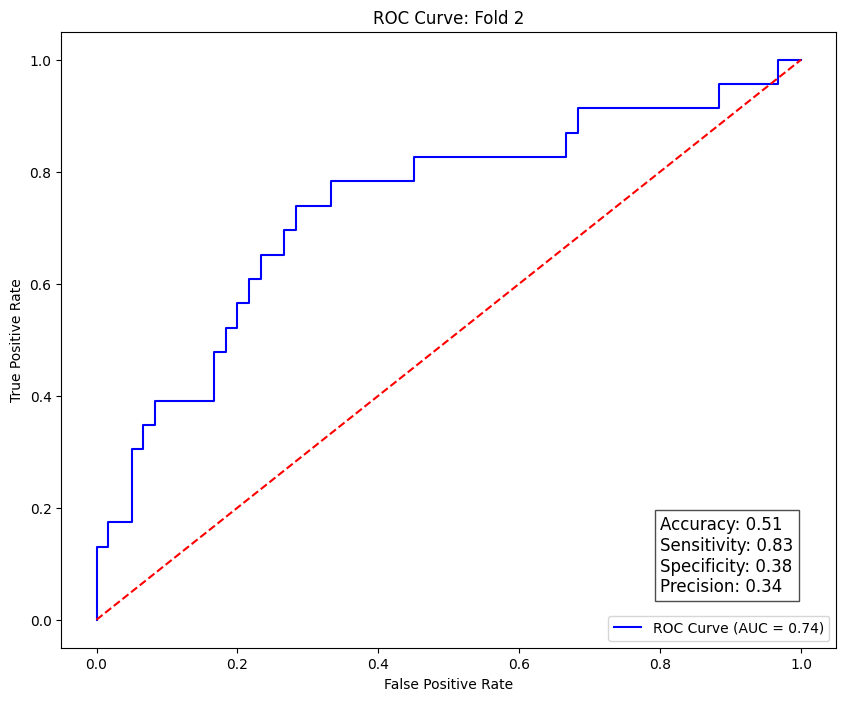

In [38]:
for best_model_per_fold in os.listdir(RESULT_DIR):
    if best_model_per_fold.endswith(".pt"):
        fold_number = best_model_per_fold.split("_")[2]
        best_model = SFCN()
        best_model_state_dict = torch.load(f'{RESULT_DIR}/{best_model_per_fold}', weights_only=True) #choose the best performing fold
        
        new_state_dict = {}
        for key, value in best_model_state_dict.items():
            new_key = key.replace("module.", "")
            new_state_dict[new_key] = value
        best_model.load_state_dict(new_state_dict)
        
        best_model.to(DEVICE)
        best_model.eval()
        test_loss = 0.0
        test_total = 0
        test_correct = 0
        
        with torch.no_grad():
            all_predicted = []
            all_labels = []
            for inputs, labels, age, gender in test_dl:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                age = age.to(DEVICE)
                gender = gender.to(DEVICE)
                
                outputs = best_model(inputs, age, gender)
                te_loss = criterion(outputs, labels)
                test_loss += te_loss.item()/inputs.size(0)
                probability = torch.sigmoid(outputs)
                predicted = (probability >= 0.5).float()
                all_predicted.extend(predicted.cpu().numpy().ravel().tolist())
                all_labels.extend(labels.cpu().numpy().ravel().tolist())
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()
        
            test_accuracy = 100 * test_correct / test_total
        
        cm = confusion_matrix(all_labels, all_predicted)
        
        print(f"TEST LOSS: {test_loss}, TEST ACCURACY: {test_accuracy}")
        LOGGER.info(f"TEST LOSS: {test_loss}, TEST ACCURACY: {test_accuracy}")
        accuracy = accuracy_score(all_labels, all_predicted)
        sensitivity = recall_score(all_labels, all_predicted)
        specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
        precision = precision_score(all_labels, all_predicted)
        
        print(f'Accuracy: {accuracy}, Sensitivity (Recall): {sensitivity}, Specificity: {specificity}, Precision: {precision}')
        LOGGER.info(f'Accuracy: {accuracy}, Sensitivity (Recall): {sensitivity}, Specificity: {specificity}, Precision: {precision}')
        
        print('CM: ',cm)
        LOGGER.info(f"CM for Fold {fold_number} : {cm}")
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",xticklabels=['Healthy', 'AD'], yticklabels=['Healthy', 'AD'])
        plt.title(f'Confusion Matrix: Fold {fold_number}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.savefig(f'cm_fold{fold_number}.png')

        # Plot ROC Curve
        fpr, tpr, thresholds = roc_curve(all_labels, all_probabilities)
        auc_score = roc_auc_score(all_labels, all_probabilities)
        
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
        plt.plot([0, 1], [0, 1], color='red', linestyle='--')
        plt.title(f'ROC Curve: Fold {fold_number}')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc='lower right')

        # Annotate the metrics on the plot
        text = (
            f"Accuracy: {accuracy:.2f}\n"
            f"Sensitivity: {sensitivity:.2f}\n"
            f"Specificity: {specificity:.2f}\n"
            f"Precision: {precision:.2f}"
        )
        plt.text(0.8, 0.05, text, fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

        plt.savefig(f'roc_fold{fold_number}.png')